In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.peint import EncodedPEINTDataset
from peint.models.modules.peint_module import PEINTModule
from peint.models.nets.peint import PEINT, PEINTGenerator

from evo.tensor import collate_tensors
from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab
from esm.data import Alphabet

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Load trained joint model from checkpoint
# ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-11-01_03-40-52/checkpoints")
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/logs/train/runs/2025-12-03_00-13-31/checkpoints")
ckpt_path = ckpt_dir / "epoch_010.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = PEINTModule.load_from_checkpoint(ckpt_path, map_location=device, strict=True)
module = module.eval()
net: PEINT = module.net
vocab: Vocab = net.vocab
print(vocab)

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


Vocab({'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4, 'A': 5, 'G': 6, 'V': 7, 'S': 8, 'E': 9, 'R': 10, 'T': 11, 'I': 12, 'D': 13, 'P': 14, 'K': 15, 'Q': 16, 'N': 17, 'F': 18, 'Y': 19, 'M': 20, 'H': 21, 'W': 22, 'C': 23, 'X': 24, 'B': 25, 'U': 26, 'Z': 27, 'O': 28, '.': 29, '-': 30, '<null_1>': 31, '<mask>': 32})


In [4]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = EncodedPEINTDataset(
        dataset=ComplexCherriesDataset(sep_token=".", data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        sep_token=".",
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        permute_chain_order=False,
        embed_x_per_chain=True,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(ts.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    toks_to_skip = [
        vocab.bos_idx,
        vocab.unk_idx,
        vocab.tokens_to_idx["<mask>"],
        vocab.tokens_to_idx["<null_1>"],
        vocab.tokens_to_idx["-"],
    ]
    for tok in toks:
        if tok in toks_to_skip:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)

def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [5]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/aa/dx.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
# lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

In [36]:
# run inference on the dataloader
n_batches = -1

lls, bls, ppl = [], [], []
all_hv_szs, all_lt_szs = [], []
all_hv_nlls, all_lt_nlls = [], []

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
    yt_mask = y_tgt != vocab.pad_idx  # actual values

    # get heavy chain lengths
    y_hv_sz = y_sizes[:,0]-1
    y_lt_sz = y_sizes[:,1]

    # get the true child sequences
    true_child_seqs = [decode_sequence_from_toks(y_tgt[i].cpu().numpy()) for i in range(y_tgt.size(0))]
    true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, y_hv_sz)])

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
        x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

    y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
    y_logits = y_logits.transpose(-1, -2)
    nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

    # separate nlls by heavy chain and light chain
    nll = nll.detach().cpu().numpy()
    hv_nlls = [nll[i, :L] for i, L in enumerate(y_hv_sz)]
    lt_nlls = [nll[i, L+1:L+y_lt_sz[i]] for i, L in enumerate(y_hv_sz)]
    assert all([len(hvll) == len(hvc) for hvll, hvc in zip(hv_nlls, true_ch_hv_seqs)])
    assert all([len(ltll) == len(ltc) for ltll, ltc in zip(lt_nlls, true_ch_lt_seqs)])
    
    all_hv_nlls.extend(hv_nlls)
    all_lt_nlls.extend(lt_nlls)
    all_hv_szs.append(y_hv_sz.cpu().numpy())
    all_lt_szs.append(y_lt_sz.cpu().numpy())
    bls.append(ts.detach().cpu().numpy())

    # ll = -nll * yt_mask.float()
    # ll = ll.sum(dim=-1)
    # lls.append(ll.detach().cpu().numpy())

    # nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
    # bls.append(ts.detach().cpu().numpy())
    ppl.append(np.exp(nll.mean(-1)))

    n_batches -= 1
    if n_batches == 0:
        break

# lls = np.concatenate(lls)
# bls = np.concatenate(bls)
# ppl = np.concatenate(ppl)

Inference: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1888/1888 [11:22<00:00,  2.77it/s]


In [40]:
# pad the nlls to the same length
hv_nlls_padded = collate_tensors(all_hv_nlls, constant_value=0.0)
lt_nlls_padded = collate_tensors(all_lt_nlls, constant_value=0.0)
hv_szs = np.concatenate(all_hv_szs)
lt_szs = np.concatenate(all_lt_szs)
bls = np.concatenate(bls)

print(hv_nlls_padded.shape, lt_nlls_padded.shape, hv_szs.shape, lt_szs.shape, bls.shape)

(60403, 144) (60403, 119) (60403,) (60403,) (60403, 2)


In [41]:
# combine these numpy arrays into a numpy structured array and save to disk
save_path = "/accounts/projects/yss/stephen.lu/peint/results/inf_eval"
np.savez(f"{save_path}/peint_650m_nlls_d4.npz", hv_nlls=hv_nlls_padded, lt_nlls=lt_nlls_padded, hv_szs=hv_szs, lt_szs=lt_szs, bls=bls[:,0])

In [44]:
print('test perplexity: ', np.mean(ppl))

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch": bls[:,0],
    # "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("peint_650m_model_d4.csv", index=False)

test perplexity:  1.2234846


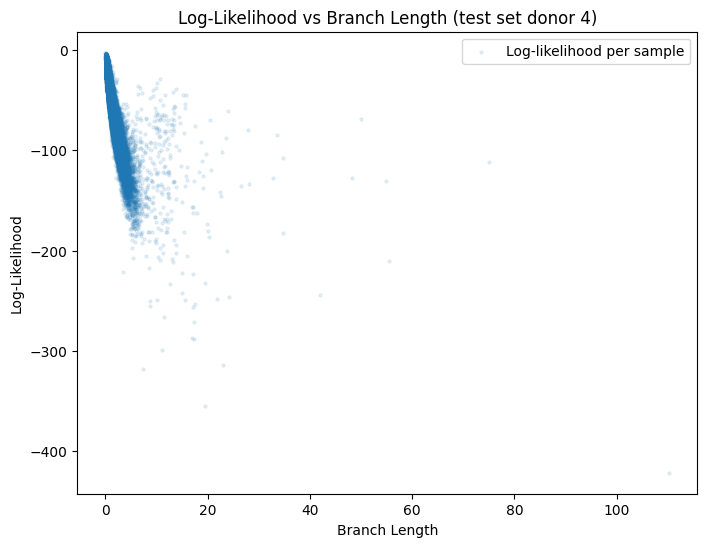

In [10]:
# plot the binned likelihoods according to the branch length
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(.15).astype(float)
binned_df = df.groupby("bl_bin").mean()

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(binned_df.branch_length, binned_df.ll, label="Binned log-likelihood", s=10)
ax.scatter(df.branch_length, df.ll, alpha=0.1, label="Log-likelihood per sample", s=5)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Log-Likelihood vs Branch Length (test set donor 4)")
ax.legend()
plt.show()

## Sampling from PEINT

In [57]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

# load the generator from the peint model
generator = PEINTGenerator.from_peint(module.net).to(device)

In [ ]:
# first we try generating child sequences using the one-shot independent site method
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
sim_child_hv_seqs, sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 50

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

    # get heavy chain lengths
    x_hc_lens = x_sizes[:,0]-1
    y_hc_lens = y_sizes[:,0]-1

    # decode the true parent and child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x_src[i].cpu().numpy()) for i in range(x_src.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y_tgt[i].cpu().numpy()) for i in range(y_tgt.size(0))]
    true_pr_hv_seqs, true_pr_lt_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(true_parent_seqs, x_hc_lens)])
    true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, y_hc_lens)])

    # sample a child sequence using the model
    y_sizes[:,1] += 1
    y_decoded = generator.dec_generate(ts=ts, xs=x_src, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
    sim_child_seqs = [decode_sequence_from_toks(y_decoded[i].cpu().numpy()) for i in range(y_decoded.size(0))]
    sim_hv_seqs, sim_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_child_seqs, y_hc_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_child_seqs)])

    real_parent_hv_seqs.extend(true_pr_hv_seqs)
    real_parent_lt_seqs.extend(true_pr_lt_seqs)
    real_child_hv_seqs.extend(true_ch_hv_seqs)
    real_child_lt_seqs.extend(true_ch_lt_seqs)
    sim_child_hv_seqs.extend(sim_hv_seqs)
    sim_child_lt_seqs.extend(sim_lt_seqs)
    branch_lengths.extend(ts[:,0].squeeze().detach().cpu().numpy().tolist())

    n_batches -= 1
    if n_batches == 0:
        break

In [80]:
print(true_parent_seqs[0])
# print(true_pr_hv_seqs[0])
print(true_pr_lt_seqs[0])

print()

print(true_child_seqs[0])
# print(true_ch_hv_seqs[0])
print(true_ch_lt_seqs[0])

EVHLVESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSSDIVLTQSPLSLPVTPGEPASISCRSTQSLLHTNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK
DIVLTQSPLSLPVTPGEPASISCRSTQSLLHTNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK

EVNLVESGGGLVQRGGSLRLSCAASGFTFGNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSS.DIVLTQSPLSLPVTPGEPASISCRSTQSLLHPNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK
DIVLTQSPLSLPVTPGEPASISCRSTQSLLHPNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK


In [81]:
# for tc, sc in zip(true_child_seqs, sim_child_seqs):
#     if len(tc) != len(sc):
#         print(f"Length mismatch: {len(tc)} vs {len(sc)}")
#         print(tc)
#         print(sc)

print(true_child_seqs[0])
print(sim_child_seqs[0])

EVNLVESGGGLVQRGGSLRLSCAASGFTFGNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSS.DIVLTQSPLSLPVTPGEPASISCRSTQSLLHPNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK
EVHLVESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLEWVLSISGSGSTAHYAESVKGRFTVSRDNSKNTLYVQMNTLRADDTAKYYCAKSGKTVWSLDNWGQGTLVTVSS.DIVLTQSPLSLPVTPGEPASISCRSTQSLLHTDGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRVEAEDVGVYYCMQTLQNPPITFGQGTRLEIK


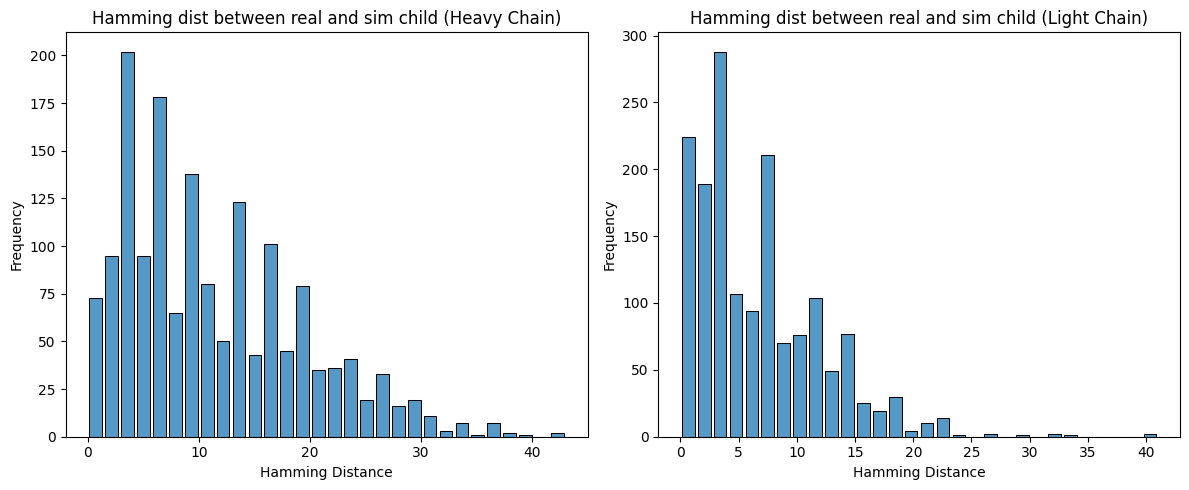

In [82]:
# calculate hamming distances between corresponding real and simulated sequences
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

hv_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, sim_child_hv_seqs)]
lt_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, sim_child_lt_seqs)]
_len = len(hv_aa_hamming_dists)

data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths,
    "dist": hv_aa_hamming_dists + lt_aa_hamming_dists,
    "chain": ["heavy"] * _len + ["light"] * _len,
})

# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side) colored by method
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data_df[data_df["chain"] == "heavy"], x="dist", multiple="dodge", shrink=0.8, bins=30, ax=ax[0])
sns.histplot(data=data_df[data_df["chain"] == "light"], x="dist", multiple="dodge", shrink=0.8, bins=30, ax=ax[1])

# add labels and legend please
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency')
ax[1].set_title('Hamming dist between real and sim child (Light Chain)')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [83]:
print(real_parent_hv_seqs[0])
print(real_child_hv_seqs[0])

QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLEWVAVIWYDGSNKYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDLWDSGFKFLDYWGQGTLVTVSS
QVQLVESGGGVVQPGRSLRLSCAASGFTFSTYGMHWVRQAPGKGLEWLALIWYDGSKRYDADSVKGRFTISRDNSKNMLYLQMNSLRAEDTAVYYCARDLWDSGFKFLDYWGQGTLVTVSS


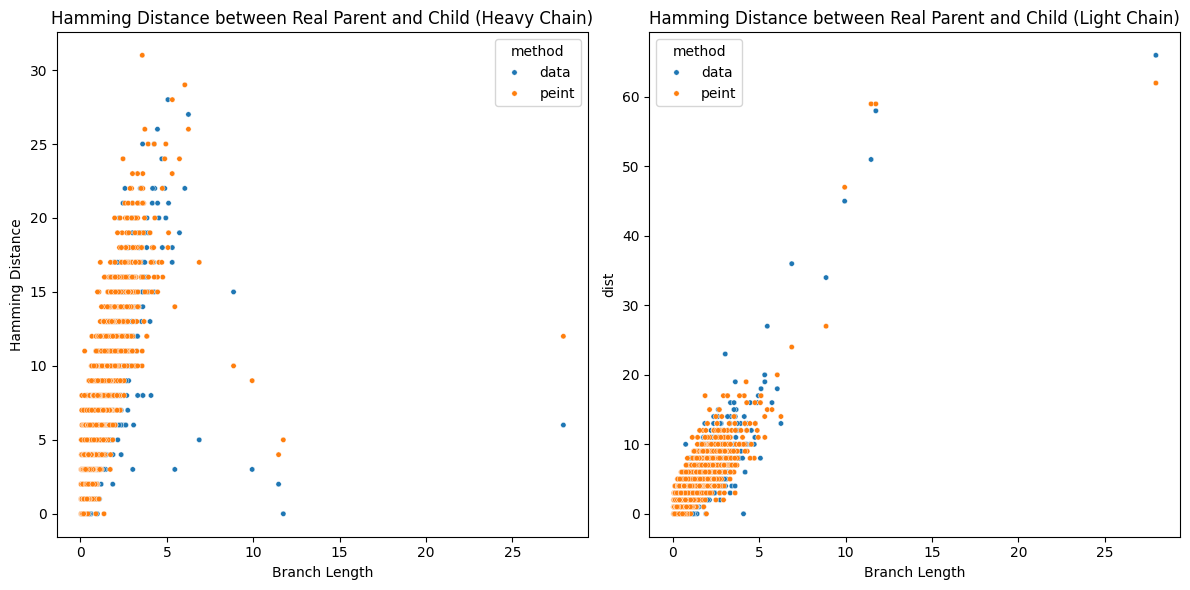

In [84]:
# calculate hamming distance between real parent and all child sequences, real and fake

hv_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, real_child_hv_seqs)]
hv_sim_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, sim_child_hv_seqs)]

lt_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, real_child_lt_seqs)]
lt_sim_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, sim_child_lt_seqs)]

_len = len(hv_real_hd)

hv_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths,
    "dist": hv_real_hd + hv_sim_hd, 
    "method": ["data"] * _len + ["peint"] * _len,
})
lt_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths,
    "dist": lt_real_hd + lt_sim_hd,
    "method": ["data"] * _len + ["peint"] * _len,
})
     

# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=hv_data_df, x="bl", y="dist", hue="method", ax=ax[0], legend="full", s=15)
sns.scatterplot(data=lt_data_df, x="bl", y="dist", hue="method", ax=ax[1], legend="full", s=15)

ax[0].set_title("Hamming Distance between Real Parent and Child (Heavy Chain)")
ax[1].set_title("Hamming Distance between Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [85]:
# save sampled sequences to disk, use different file for dep and ind methods
# format should be csv with real parent, real child, simulated child, and branch length

# Create DataFrames for peint samples
data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": sim_child_hv_seqs,
    "sim_child_lt": sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

data_df = pd.DataFrame(data)

# Save to CSV files
data_df.to_csv("notebooks/gen_eval/peint.csv", index=False)

## Sampling from same parent with different branch lengths


In [19]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

# load the generator from the peint model
generator = PEINTGenerator.from_peint(module.net).to(device)

In [24]:
# first we try generating child sequences using the one-shot independent site method
batch = next(iter(dataloader))
batch = [b.to(device) for b in batch]
[x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

x_hv_sz = x_sizes[0,0]-1
y_hv_sz = y_sizes[0,0]-1

real_parent_seq = decode_sequence_from_toks(x_src[0].cpu().numpy())
real_child_seq = decode_sequence_from_toks(y_tgt[0].cpu().numpy())
real_pr_hv_seq = real_parent_seq[:x_hv_sz]
real_pr_lt_seq = real_parent_seq[x_hv_sz:]
real_ch_hv_seq = real_child_seq[:y_hv_sz]
real_ch_lt_seq = real_child_seq[y_hv_sz+1:]

branch_lengths = torch.from_numpy(np.linspace(0, 50, 100))
xs = x_src[0].repeat(len(branch_lengths), 1).cuda()
x_sizes = x_sizes[0].repeat(len(branch_lengths), 1).cuda()
y_sizes = y_sizes[0].repeat(len(branch_lengths), 1).cuda()
y_sizes[:,1] += 1
chain_ids = chain_ids[0].repeat(len(branch_lengths), 1).cuda()
ts = branch_lengths.reshape(-1, 1).cuda().float().repeat(1, 2)

y_decoded = generator.dec_generate(ts=ts, xs=xs, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
sim_child_seqs = [decode_sequence_from_toks(y_decoded[i].cpu().numpy()) for i in range(y_decoded.size(0))]
sim_hv_seqs, sim_lt_seqs = zip(*[(seq[:y_hv_sz], seq[y_hv_sz+1:]) for seq in sim_child_seqs])

 23%|███████████████████████████████████████████                                                                                                                                                    | 230/1020 [00:10<00:34, 22.72it/s]


In [31]:
print(xs[0].shape)
# print(x_sizes[0][:2])
# print(y_sizes[0][:2])
# print(chain_ids[0])
# print(ts[0])
print(y_decoded[0].shape)

torch.Size([238])
torch.Size([232])


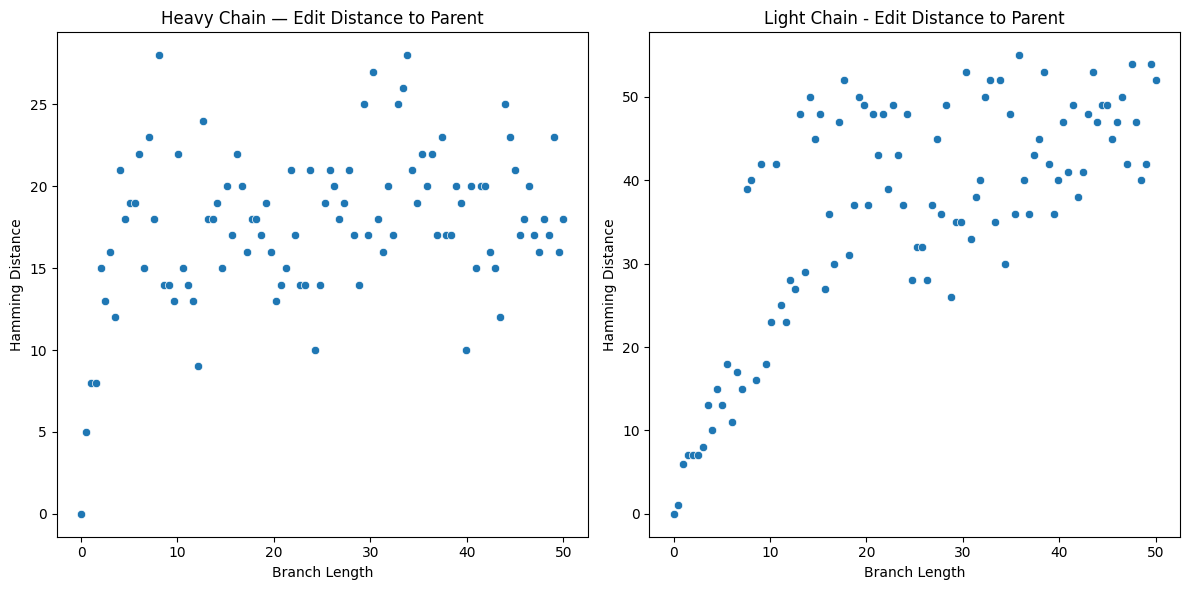

In [10]:
# calculate hamming distance between each of the simulated sequences and the real parent sequence
hv_hmd = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_hv_seqs]
lt_hmd = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_lt_seqs]

# plot hmd against branch lengths, color by method
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=branch_lengths, y=hv_hmd, ax=ax[0])
sns.scatterplot(x=branch_lengths, y=lt_hmd, ax=ax[1])

ax[0].set_title("Heavy Chain — Edit Distance to Parent")
ax[1].set_title("Light Chain - Edit Distance to Parent")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [ ]:
# save to disk
data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_hv_seqs,
    "lt_seqs": sim_lt_seqs,
    "hv_hmd": hv_hmd,
    "lt_hmd": lt_hmd,
}

# save to csv files
data_df = pd.DataFrame(data)
data_df.to_csv("results/gen_eval/peint_vary_t.csv", index=False)

## Starting from seed sequence, sample sequences up to branch length of 50 like in previous experiment

For this experiment, I want to measure the self-consistency of the CTMC model. Specifically, I want to see if I start from a seed sequence and sample trajectories of t=50 using different step sizes, do I get similar distribution of sequences at the end. If the model is consistent, then the distribution of sequences sampled with small step sizes should be identical to the distribution of sequences sampled with large step sizes, since both are sampling from the same CTMC model over the same overall time interval.

In [ ]:
from Bio.Seq import Seq
from evo.phylogeny import df_to_ete3_tree

In [7]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/raw")

heavy = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igh_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
kappa = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igk_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
lambd = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igl_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)

heavy['family'] = heavy['sample_id'] + '_' + heavy['family'].astype(str)
kappa['family'] = kappa['sample_id'] + '_' + kappa['family'].astype(str)
lambd['family'] = lambd['sample_id'] + '_' + lambd['family'].astype(str)

heavy['edge_id'] = heavy['family'] + ';' + heavy['parent_name'] + ';' + heavy['child_name']
kappa['edge_id'] = kappa['family'] + ';' + kappa['parent_name'] + ';' + kappa['child_name']
lambd['edge_id'] = lambd['family'] + ';' + lambd['parent_name'] + ';' + lambd['child_name']

In [8]:
keep_kappa = (kappa.edge_id.isin(heavy.edge_id)) & ~(kappa.edge_id.isin(lambd.edge_id))
keep_lambd = (lambd.edge_id.isin(heavy.edge_id)) & ~(lambd.edge_id.isin(kappa.edge_id))
kappa = kappa[keep_kappa]
lambd = lambd[keep_lambd]
keep_heavy = (heavy.edge_id.isin(kappa.edge_id)) | (heavy.edge_id.isin(lambd.edge_id))
heavy = heavy[keep_heavy]

In [9]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
keep_cols = ['parent', 'child', 'branch_length', 'depth', 'distance', 'v_gene', 'cdr1_codon_start', 
             'cdr1_codon_end', 'cdr2_codon_start', 'cdr2_codon_end', 'cdr3_codon_start', 'cdr3_codon_end',
             'parent_is_naive', 'child_is_leaf']
keep_cols = merge_cols + keep_cols

In [10]:
heavy_kappa = pd.merge(heavy[keep_cols], kappa[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(heavy[keep_cols], lambd[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)

In [12]:
family = 'd4_203694-igk-203694'
edges = full_df[full_df.family == family]

edges = edges.rename(columns={'branch_length_heavy':'branch_length'})
edges['branch_length'] /= edges['branch_length'].mean()

tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])

In [13]:
# translate amino acid sequences from nucleotide sequences
edges['parent_heavy_aa'] = edges['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
edges['parent_light_aa'] = edges['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
edges['child_heavy_aa'] = edges['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
edges['child_light_aa'] = edges['child_light'].progress_apply(lambda x: str(Seq(x).translate()))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:00<00:00, 25119.21it/s]


In [39]:
def prepare_batch_from_seqs(hv_seqs: list[str], lt_seqs: list[str]):
    xs = []
    for hv_seq, lt_seq in zip(hv_seqs, lt_seqs):
        x_enc = torch.cat([torch.from_numpy(vocab.encode_single_sequence(x)) for x in [hv_seq, lt_seq]], dim=0)
        xs.append(x_enc)
    xs = collate_tensors(xs, constant_value=vocab.pad_idx).to(device)
    return xs

In [64]:
# extract root and leaves from the tree
root_data = edges[edges.parent_name == "naive"].iloc[0][["parent_heavy_aa", "parent_light_aa"]]
root_seq = root_data.parent_heavy_aa + "." + root_data.parent_light_aa

leaf_data = edges[edges.child_name.str.contains("contig")][["child_name", "child_heavy_aa", "child_light_aa"]]
leaf_data["child_seq"] = leaf_data.child_heavy_aa + "." + leaf_data.child_light_aa

# calculate x_sizes from the root sequence since we want to have same length samples
xs = root_seq.split(".")

# get lens for heavy and light chains
hv_len = len(xs[0])
lt_len = len(xs[1])

x_sizes = torch.tensor([len(x) + vocab.prepend_bos + vocab.append_eos for x in xs], dtype=torch.long)
y_sizes = x_sizes.clone()
chain_ids = torch.tensor([1, 2], dtype=torch.long)
xs = torch.cat([torch.from_numpy(vocab.encode_single_sequence(x)) for x in xs], dim=0)
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

# load the generator from the peint model
generator = PEINTGenerator.from_peint(module.net).to(device)

print("Root Sequence: ")
print(root_seq)
print(len(root_seq))

Root Sequence: 
EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLEWVSYISSSGSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCASGGYCTNGVCYTAEYFQHWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQYNSYPWTFGQGTKVEIK
234


In [66]:
print(x_sizes[0:2], y_sizes[0:2])
print(hv_len, lt_len)

tensor([127, 108]) tensor([127, 108])
126 107


In [74]:
total_sim_time = 25.0
n_samples_per_step = 100
n_retries = 3
step_sizes = [1.0, 2.0, 5.0, 10.0, 25.0, 50.0]

step_size_to_simulated_hv_seqs = defaultdict(list)
step_size_to_simulated_lt_seqs = defaultdict(list)

for step_size in step_sizes:
    print(f"Simulating with step size: {step_size}")
    n_steps = int(total_sim_time / step_size)
    
    # prepare batch of size n_samples_per_step
    x_batch = xs.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    x_sizes_batch = x_sizes.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    y_sizes_batch = x_sizes_batch.clone()
    y_hv_lens = y_sizes_batch[:,0] - 1
    chain_ids_batch = chain_ids.unsqueeze(0).repeat(n_samples_per_step, 1).to(device)
    t_batch = torch.full((n_samples_per_step, 2), step_size, dtype=torch.float32).to(device)
    
    for _ in tqdm(range(n_steps)):
        while True:
            try:
                with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16): 
                    y_dec = generator.dec_generate(
                        ts=t_batch,
                        xs=x_batch,
                        x_sizes=x_sizes_batch,
                        y_sizes=y_sizes_batch,
                        chain_ids=chain_ids_batch
                    )
                
                sim_child_seqs = [decode_sequence_from_toks(y_dec[i].cpu().numpy()) for i in range(y_dec.size(0))]
                sim_hv_seqs, sim_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_child_seqs, y_hv_lens)])
                assert all([len(hv_ch) == hv_len for hv_ch in sim_hv_seqs])
                assert all([len(lt_ch) == lt_len for lt_ch in sim_lt_seqs])
                x_batch = prepare_batch_from_seqs(sim_hv_seqs, sim_lt_seqs)
                break
            except Exception as e:
                print(f"Error during generation: {e}. Retrying...")
                n_retries -= 1
                if n_retries == 0:
                    raise e

        n_retries = 3  # reset retries for next step
            
    step_size_to_simulated_hv_seqs[step_size].extend(sim_hv_seqs)
    step_size_to_simulated_lt_seqs[step_size].extend(sim_lt_seqs)

Simulating with step size: 2.0


 23%|███████████████████████████████████████████▋                                                                                                                                                   | 233/1020 [00:09<00:33, 23.76it/s]


Error during generation: . Retrying...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [02:13<00:00, 11.12s/it]


Simulating with step size: 5.0


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:20<00:00, 10.28s/it]


Simulating with step size: 25.0


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:10<00:00, 10.28s/it]


Simulating with step size: 50.0


0it [00:00, ?it/s]


In [80]:
# combine the heavy and light chain sequences into full sequences with a dot separator
step_size_to_simulated_seqs = {}

for step_size in step_sizes:
    hv_seqs = step_size_to_simulated_hv_seqs[step_size]
    lt_seqs = step_size_to_simulated_lt_seqs[step_size]
    combined_seqs = [hv + "." + lt for hv, lt in zip(hv_seqs, lt_seqs)]
    step_size_to_simulated_seqs[step_size] = combined_seqs

In [81]:
# calculate the wasserstein distance between the distribution of sequences generated at different step sizes for each method

from scipy.stats import wasserstein_distance
from peint.metrics.esm2 import compute_mmd

sim_wasserstein_dists = np.zeros((len(step_sizes), len(step_sizes)))
sim_mmds = np.zeros((len(step_sizes), len(step_sizes)))

for i, step_size_i in tqdm(enumerate(step_sizes)):
    for j, step_size_j in enumerate(step_sizes):
        if i >= j:
            continue
        seqs_i = step_size_to_simulated_seqs[step_size_i]
        seqs_j = step_size_to_simulated_seqs[step_size_j]
        
        # compute hamming distances between all pairs of sequences from the two sets
        hdists = [compute_hamming_distance(s1, s2) for s1 in seqs_i for s2 in seqs_j]
        
        # compute wasserstein distance between the two distributions of hamming distances
        sim_wasserstein_dists[i, j] = wasserstein_distance(hdists, hdists)
        
        # compute mmd between the two sets of sequences
        sim_mmds[i, j] = compute_mmd(seqs_i, seqs_j, device="cuda")

6it [00:42,  7.07s/it]


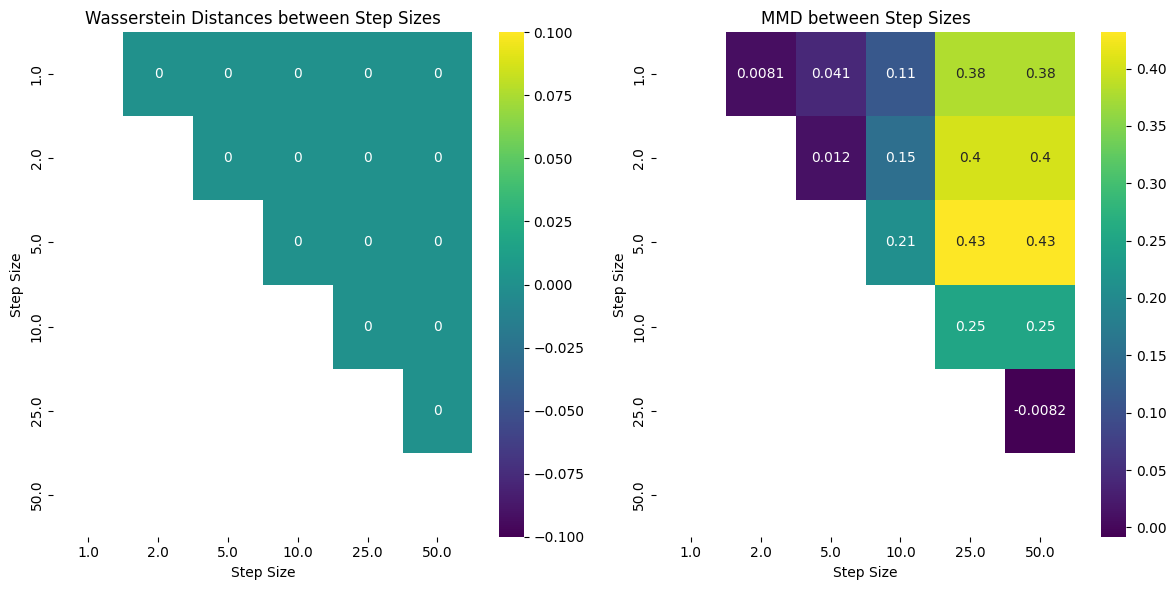

In [82]:
# plot the pairwise wasserstein distances and mmds as heatmaps side by side (upper triangular matrices)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(sim_wasserstein_dists, xticklabels=step_sizes, yticklabels=step_sizes, ax=ax[0], cmap="viridis", annot=True, mask=np.tril(np.ones_like(sim_wasserstein_dists, dtype=bool)))
sns.heatmap(sim_mmds, xticklabels=step_sizes, yticklabels=step_sizes, ax=ax[1], cmap="viridis", annot=True, mask=np.tril(np.ones_like(sim_mmds, dtype=bool)))
ax[0].set_title("Wasserstein Distances between Step Sizes")
ax[1].set_title("MMD between Step Sizes")
ax[0].set_xlabel("Step Size")
ax[0].set_ylabel("Step Size")
ax[1].set_xlabel("Step Size")
ax[1].set_ylabel("Step Size")
plt.tight_layout()
plt.show()

In [83]:
# save samples for each method to disk, indexed by step size using two csv files
# Create DataFrames for independent and dependent methods
data = {
    "step_size": [],
    "simulated_sequence": [],
}
for step_size in step_sizes:
    simulated_seqs = step_size_to_simulated_seqs[step_size]
    data["step_size"].extend([step_size] * len(simulated_seqs))
    data["simulated_sequence"].extend(simulated_seqs)

df = pd.DataFrame(data)
df.to_csv("results/gen_eval/peint_step_size_samples.csv", index=False)